# Analyse exploratoire des données (langage R)

In [2]:
# Chargement des librairies nécessaires
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : 'gridExtra'


L'objet suivant est masqué depuis 'package:dplyr':

    combine



Attachement du package : 'plotly'


L'objet suivant est masqué depuis 'package:ggplot2':

    last_plot


L'objet suivant est masqué depuis 'package:stats':

    filter


L'objet suivant est masqué depuis 'package:graphics':

    layout


corrplot 0.95 loaded


Attachement du package : 'reshape2'


L'objet suiv

In [3]:
data= read.table("C:\\Users\\Utilisateur\\Desktop\\Projet_Machine_Learning\\healthcare_synthetic_data.csv",sep=",",header=TRUE)
#head(data)
#summary(data)

**Transformation des données**

In [4]:
#on enlève patient_ID ( A EXECUTER 1 SEULE FOIS)
data=data[,-1]

In [5]:
#Changement du type des variables qualitatives en facteurs
data[,"Gender"]= as.factor(data[,"Gender"])
data[,"Smoking_Status"]= as.factor(data[,"Smoking_Status"])
data[,"Alcohol_Consumption"]= as.factor(data[,"Alcohol_Consumption"])
data[,"Physical_Activity_Level"]= as.factor(data[,"Physical_Activity_Level"])
data[,"Family_History"]= as.factor(data[,"Family_History"])
data[,"Stress_Level"]= as.factor(data[,"Stress_Level"])
data[,"Heart_Disease_Risk"]= as.factor(data[,"Heart_Disease_Risk"])
data[,"Sleep_Hours"]= as.factor(data[,"Sleep_Hours"])


In [6]:
#Tranformation (racine carrée) de Weight_kg et BMI pour centrer les densitées
options(repr.plot.width = 10, repr.plot.height = 5)
data[,"SBMI"]=sqrt(data[,"BMI"])
data[,"SWeight"]=sqrt(data[,"Weight_kg"])
data[,"S_Fasting_Blood_Sugar"] = sqrt(data[,"Fasting_Blood_Sugar"])
data[,"L_Height_cm"]=log(data[,"Height_cm"])

data = data %>% select(-c(BMI,Weight_kg,Fasting_Blood_Sugar,Height_cm))
summary(data)


      Age        Gender    Systolic_BP     Diastolic_BP    Cholesterol_Total
 Min.   :25.00   0:7622   Min.   : 90.0   Min.   : 60.00   Min.   :127.0    
 1st Qu.:46.00   1:7378   1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0    
 Median :55.00            Median :135.0   Median : 91.00   Median :216.0    
 Mean   :54.54            Mean   :135.1   Mean   : 90.54   Mean   :216.2    
 3rd Qu.:63.00            3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0    
 Max.   :85.00            Max.   :182.0   Max.   :120.00   Max.   :303.0    
                                                                            
 Cholesterol_LDL Cholesterol_HDL Smoking_Status Alcohol_Consumption
 Min.   : 70.0   Min.   :20.00   0:10495        0:7502             
 1st Qu.:128.0   1st Qu.:39.00   1: 4505        1:5939             
 Median :140.0   Median :43.00                  2:1559             
 Mean   :140.4   Mean   :43.31                                     
 3rd Qu.:152.0   3rd Qu.:47.00              

# Prediction de la variable Heart_Disease_Risk

## 1.Division du jeu de données en un échantillon d’apprentissage et un échantillon test

Pourquoi cette étape est-elle nécessaire lorsque nous nous concentrons sur les performances des algorithmes ?

In [7]:
library(caret)

Le chargement a nécessité le package : lattice


Attachement du package : 'caret'


L'objet suivant est masqué depuis 'package:purrr':

    lift




In [8]:
set.seed(131)
trainIndex = createDataPartition(data$Heart_Disease_Risk,p=0.8,list = FALSE)
dataTrain0 = data[ trainIndex,]
dataTest0 = data[-trainIndex,]

In [9]:
dataTrain=dataTrain0
dataTrain[,-c(2,8,9,10,11,12,13,14)]=scale(dataTrain0[,-c(2,8,9,10,11,12,13,14)])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
dataTest=dataTest0
dataTest[,-c(2,8,9,10,11,12,13,14)]=scale(dataTest0[,-c(2,8,9,10,11,12,13,14)],
                            center=sapply(dataTrain0[,-c(2,8,9,10,11,12,13,14)],mean), # on centre avec les moyennes de l'échantillon d'apprentissage
                            scale=sapply(dataTrain0[,-c(2,8,9,10,11,12,13,14)],sd)) # on réduit avec les écart-types de l'échantillon d'apprentissage
summary(dataTrain)
summary(dataTest)

      Age           Gender    Systolic_BP        Diastolic_BP     
 Min.   :-2.50056   0:6126   Min.   :-4.00425   Min.   :-3.62845  
 1st Qu.:-0.64148   1:5874   1st Qu.:-0.63600   1st Qu.:-0.66295  
 Median : 0.03455            Median :-0.01553   Median : 0.04877  
 Mean   : 0.00000            Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.71058            3rd Qu.: 0.69357   3rd Qu.: 0.64187  
 Max.   : 2.56965            Max.   : 4.15046   Max.   : 3.48876  
                                                                  
 Cholesterol_Total  Cholesterol_LDL    Cholesterol_HDL    Smoking_Status
 Min.   :-3.71524   Min.   :-3.92744   Min.   :-3.91739   0:8401        
 1st Qu.:-0.67272   1st Qu.:-0.69168   1st Qu.:-0.72723   1:3599        
 Median :-0.01131   Median :-0.02221   Median :-0.05562                 
 Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000                 
 3rd Qu.: 0.65011   3rd Qu.: 0.64725   3rd Qu.: 0.61599                 
 Max.   : 3.82491   Max.  

      Age           Gender    Systolic_BP        Diastolic_BP     
 Min.   :-2.50056   0:1496   Min.   :-3.02923   Min.   :-3.62845  
 1st Qu.:-0.72598   1:1504   1st Qu.:-0.72464   1st Qu.:-0.66295  
 Median :-0.04996            Median :-0.01553   Median :-0.06985  
 Mean   :-0.02241            Mean   :-0.02552   Mean   :-0.02821  
 3rd Qu.: 0.64720            3rd Qu.: 0.60493   3rd Qu.: 0.64187  
 Max.   : 2.56965            Max.   : 3.17544   Max.   : 3.48876  
                                                                  
 Cholesterol_Total   Cholesterol_LDL    Cholesterol_HDL    Smoking_Status
 Min.   :-3.935714   Min.   :-3.87165   Min.   :-3.24577   0:2094        
 1st Qu.:-0.672724   1st Qu.:-0.69168   1st Qu.:-0.72723   1: 906        
 Median :-0.011307   Median :-0.02221   Median :-0.05562                 
 Mean   :-0.001856   Mean   :-0.01197   Mean   :-0.01963                 
 3rd Qu.: 0.650110   3rd Qu.: 0.64725   3rd Qu.: 0.61599                 
 Max.   : 3.295778  

## 2. Modèle de régression logistique

Heart_Disease_Risk est une variable binaire, on utilise donc un modèle linéaire généralisé ( régression logistique)

### Modèle sans intéraction entre les variables

In [34]:
# estimation du modèle complet(sans interactions)
reglog = glm(Heart_Disease_Risk ~. , data = dataTrain, family = binomial(link="logit"))
# significativité des paramètres
anova(reglog, test = "Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16438.38,NA
Age,1,3.330504e+02,11998,16105.33,2.081636e-74
Gender,1,5.432754e-01,11997,16104.79,4.610785e-01
Systolic_BP,1,2.272832e+02,11996,15877.51,2.332635e-51
Diastolic_BP,1,2.102715e-01,11995,15877.30,6.465547e-01
Cholesterol_Total,1,5.747755e+01,11994,15819.82,3.418599e-14
Cholesterol_LDL,1,1.913292e+01,11993,15800.69,1.219235e-05
Cholesterol_HDL,1,3.189926e+01,11992,15768.79,1.623793e-08
Smoking_Status,1,1.607143e+03,11991,14161.64,0.000000e+00


Il est pertinent de se demander si on peut simplifier le modèle en selectionnant seulement les variables significatives. On utilise d'abord le critère AIC (comparaison avec BIC ??)

In [35]:
# Recherche d'un modèle optimal au sens d'Akaïke
reglog.stepAIC = step(reglog, direction = "backward") # éventuellement tester avec direction= "both"

Start:  AIC=12736.38
Heart_Disease_Risk ~ Age + Gender + Systolic_BP + Diastolic_BP + 
    Cholesterol_Total + Cholesterol_LDL + Cholesterol_HDL + Smoking_Status + 
    Alcohol_Consumption + Physical_Activity_Level + Family_History + 
    Stress_Level + Sleep_Hours + SBMI + SWeight + S_Fasting_Blood_Sugar + 
    L_Height_cm

                          Df Deviance   AIC
- SWeight                  1    12668 12734
- L_Height_cm              1    12668 12734
- Diastolic_BP             1    12669 12735
- SBMI                     1    12669 12735
- Gender                   1    12669 12735
- Cholesterol_Total        1    12669 12735
- Alcohol_Consumption      2    12671 12735
<none>                          12668 12736
- Cholesterol_HDL          1    12674 12740
- Sleep_Hours              6    12697 12753
- Cholesterol_LDL          1    12695 12761
- Age                      1    12744 12810
- Systolic_BP              1    12746 12812
- Stress_Level             9    12865 12915
- S_Fasting_B

In [36]:
anova(reglog.stepAIC,test="Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16438.38,NA
Age,1,333.05045,11998,16105.33,2.081636e-74
Systolic_BP,1,227.16047,11997,15878.17,2.480927e-51
Cholesterol_LDL,1,75.68844,11996,15802.48,3.321459e-18
Cholesterol_HDL,1,30.50806,11995,15771.98,3.324821e-08
Smoking_Status,1,1606.48208,11994,14165.49,0.000000e+00
Physical_Activity_Level,3,386.47507,11991,13779.02,1.882025e-83
Family_History,1,597.14366,11990,13181.88,6.999670e-132
Stress_Level,9,194.27089,11981,12987.60,5.254821e-37


In [37]:
#matrice de confusion
table(reglog$fitted.values > 0.5, dataTrain[, "Heart_Disease_Risk"])
table(reglog.stepAIC$fitted.values > 0.5, dataTrain[, "Heart_Disease_Risk"])

       
           0    1
  FALSE 5497 1852
  TRUE  1271 3380

       
           0    1
  FALSE 5497 1847
  TRUE  1271 3385

### Modèle avec intéractions

Nous travaillons avec un grand nombre de variables et donc d'interactions ce qui peut donner des warnings et être long si on essaye d'estimer le modèle avec toutes les interactions possibles d'un coup. Nous allons donc utiliser deux méthodes qui permettent d'éviter le problème en selectionnant directement les variables et intéractions siginificatives:

- Une procédure stepwise de selection de variable sur critère AIC
- Une pénalisation L1 (LASSO)

In [38]:
#première méthode
# estimation du modèle avec interactions en partant du modèle constant
reglog.inter = glm(Heart_Disease_Risk ~ 1, data = dataTrain,family = binomial)
# algorithme stepwise en précisant le plus grand 
# modèle possible
reglog.inter.step = step(reglog.inter, direction = "both",
    scope = list(lower = ~1, upper = ~(Age + Gender + L_Height_cm + SWeight + SBMI + Systolic_BP + Diastolic_BP +Cholesterol_Total + Cholesterol_LDL
                                      + Cholesterol_HDL +  S_Fasting_Blood_Sugar + Smoking_Status +  Alcohol_Consumption + Physical_Activity_Level + 
                                       Family_History + Stress_Level + Sleep_Hours)^2))

      Age        Gender    Systolic_BP     Diastolic_BP    Cholesterol_Total
 Min.   :25.00   0:6126   Min.   : 90.0   Min.   : 60.00   Min.   :132.0    
 1st Qu.:47.00   1:5874   1st Qu.:128.0   1st Qu.: 85.00   1st Qu.:201.0    
 Median :55.00            Median :135.0   Median : 91.00   Median :216.0    
 Mean   :54.59            Mean   :135.2   Mean   : 90.59   Mean   :216.3    
 3rd Qu.:63.00            3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0    
 Max.   :85.00            Max.   :182.0   Max.   :120.00   Max.   :303.0    
                                                                            
 Cholesterol_LDL Cholesterol_HDL Smoking_Status Alcohol_Consumption
 Min.   : 70.0   Min.   :20.00   0:8401         0:6033             
 1st Qu.:128.0   1st Qu.:39.00   1:3599         1:4735             
 Median :140.0   Median :43.00                  2:1232             
 Mean   :140.4   Mean   :43.33                                     
 3rd Qu.:152.0   3rd Qu.:47.00              

Start:  AIC=16440.38
Heart_Disease_Risk ~ 1

                          Df Deviance   AIC
+ Smoking_Status           1    14896 14900
+ Family_History           1    15986 15990
+ Systolic_BP              1    15995 15999
+ Age                      1    16105 16109
+ S_Fasting_Blood_Sugar    1    16123 16127
+ Physical_Activity_Level  3    16129 16137
+ Diastolic_BP             1    16158 16162
+ Cholesterol_Total        1    16216 16220
+ Cholesterol_LDL          1    16216 16220
+ SBMI                     1    16246 16250
+ SWeight                  1    16299 16303
+ Stress_Level             9    16292 16312
+ Cholesterol_HDL          1    16386 16390
+ Sleep_Hours              6    16418 16432
<none>                          16438 16440
+ L_Height_cm              1    16437 16441
+ Gender                   1    16438 16442
+ Alcohol_Consumption      2    16436 16442

Step:  AIC=14900.3
Heart_Disease_Risk ~ Smoking_Status

                          Df Deviance   AIC
+ Family_History  

In [39]:
anova(reglog.inter.step, test = "Chisq")

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16438.38,NA
Smoking_Status,1,1542.083940,11998,14896.30,0.000000e+00
Family_History,1,532.760681,11997,14363.54,7.085177e-118
Systolic_BP,1,497.254186,11996,13866.29,3.761899e-110
Physical_Activity_Level,3,405.425392,11993,13460.86,1.478964e-87
S_Fasting_Blood_Sugar,1,296.847399,11992,13164.01,1.601876e-66
Stress_Level,9,190.348556,11983,12973.66,3.480213e-36
Cholesterol_LDL,1,146.286811,11982,12827.38,1.123674e-33
Age,1,58.322409,11981,12769.05,2.224952e-14


In [40]:
#Deuxième méthode
x.mat = model.matrix(Heart_Disease_Risk~(.)^2-1, data=dataTrain) # permet d'encoder les variables qualitatives

#Pour illustrer le fonctionnement de la pénalisation, l'evolution des coefficients selon la valeur de lambda
#reglog.inter.lasso = glmnet(x=x.mat,dataTrain$Heart_Disease_Risk, family="binomial", alpha=1)
#options(repr.plot.width = 12, repr.plot.height = 10)
#plot(reglog.inter.lasso, xvar = "lambda", label = TRUE)

On determine la valeur optimale du paramètre $\lambda$, associé a la pénalisation L1, par validation croisée.

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggfortify package.
  Please report the issue at <https://github.com/sinhrks/ggfortify/issues>."


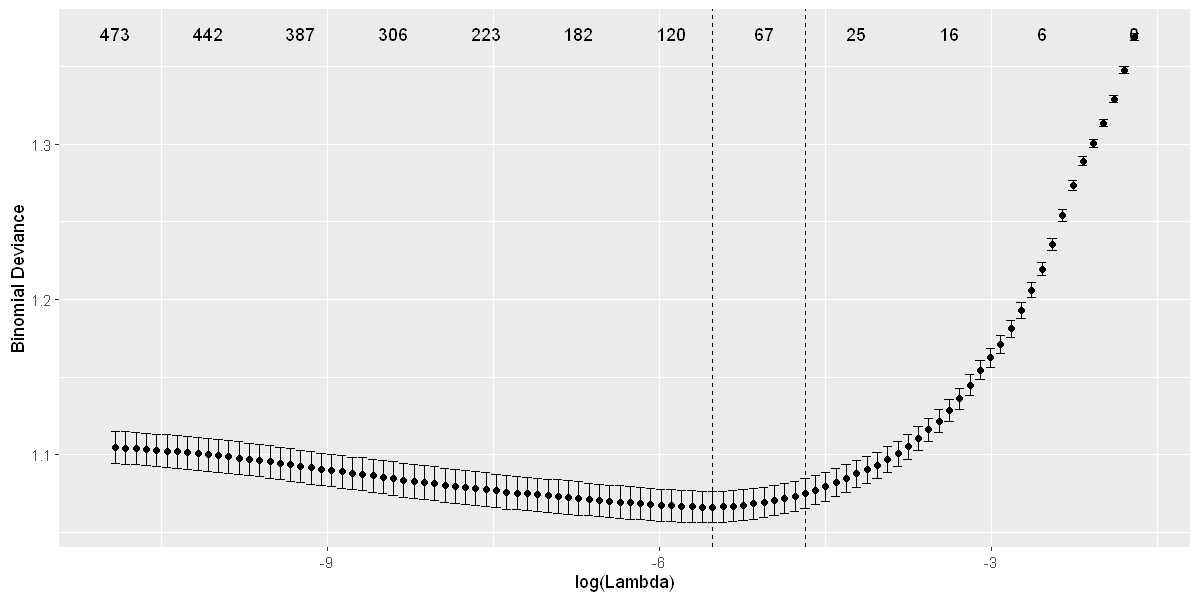

In [41]:
y_train = as.numeric(as.character(dataTrain$Heart_Disease_Risk)) #la fonction cv.glmnet ne prend pas d'objets factors
set.seed(123) #Pour que le découpage des k folds soit toujours le même
reglog.inter.lasso.cv = cv.glmnet(y=y_train, x = x.mat,family="binomial", alpha=1)
autoplot(reglog.inter.lasso.cv)

La ligne pointillée de gauche correspond à la valeur de lambda.min qui donne l'erreur de validation croisée la plus faible. La ligne de pointillé de droite correspond à la valeur de lambda.1se qui donne la plus grande valeur de lambda telle que l'erreur reste à moins d'un écart-type de l'erreur minimale. Cette valeur de lambda donne donc une plus grande pénalisation et donc un modèle plus simple, c'est elle que nous allons utiliser. 

In [42]:
# valeur estimée
paste("Valeur de lambda estimée :", round(reglog.inter.lasso.cv$lambda.1se, 3)) #round(,3) correspond au nb de décimale après la virgule
# coefficients du modèle correspondant
coef(reglog.inter.lasso.cv, s = "lambda.1se")

[1] "Valeur de lambda estimée : 0.009"

508 x 1 sparse Matrix of class "dgCMatrix"
                                                  lambda.1se
(Intercept)                                    -5.819795e+00
Age                                             .           
Gender0                                         .           
Gender1                                         .           
Systolic_BP                                     .           
Diastolic_BP                                    .           
Cholesterol_Total                               .           
Cholesterol_LDL                                 .           
Cholesterol_HDL                                 .           
Smoking_Status1                                 5.124865e-02
Alcohol_Consumption1                            .           
Alcohol_Consumption2                            .           
Physical_Activity_Level1                        .           
Physical_Activity_Level2                       -4.932917e-01
Physical_Activity_Level3                  

Nous allons comparer les variables retenues par chaque modèle:

In [43]:
# Variables du modèle par stepAIC
vars_step = names(coef(reglog.inter.step))[-1] # [-1] pour enlever l'intercept

# Variables du modèle lasso (en retenant lamda1se)
# On récupère la matrice des coefficients
coefs_lasso = coef(reglog.inter.lasso.cv, s = "lambda.1se")
# On garde les noms dont la valeur est différente de 0
vars_lasso = rownames(coefs_lasso)[which(coefs_lasso != 0)][-1] # [-1] pour l'intercept

#Variables communes aux deux modèles
communes = intersect(vars_step, vars_lasso)

# Variables le StepAIC a-t-il gardées que le LASSO a supprimées 
step = setdiff(vars_step, vars_lasso)

# Variables le LASSO a-t-il gardées que le StepAIC a supprimées 
lasso = setdiff(vars_lasso, vars_step)

paste("Nombre de variables communes:",length(communes))
paste("Nombre de variables uniquement dans le modèle stepAIC:",length(step))
paste("Nombre de variables uniquement dans le modèle LASSO:",length(lasso))

[1] "Nombre de variables communes: 3"

[1] "Nombre de variables uniquement dans le modèle stepAIC: 47"

[1] "Nombre de variables uniquement dans le modèle LASSO: 45"

Les deux modèles obtenus sont complètements différents (seulement deux variables communes). Cela peut s'expliquer par le fait que reglog.inter.step considère les variables qualitatives comme des "blocs"alors que reglog.inter.lasso.cv considère chaque modalité.

In [44]:
#Comparaisons matrices de confusions
table(reglog.inter.step$fitted.values > 0.5, dataTrain[, "Heart_Disease_Risk"])
proba_lasso = predict(reglog.inter.lasso.cv, newx = x.mat, type = "response")  
table(proba_lasso > 0.5,dataTrain$Heart_Disease_Risk)

       
           0    1
  FALSE 5473 1811
  TRUE  1295 3421

       
           0    1
  FALSE 5576 1988
  TRUE  1192 3244

### Prévision de l'échantillon test

**Matrices de confusions**

In [45]:
#Prévision modèle sans interaction sans selection de variable
pred.log <- predict(reglog, newdata = dataTest, type = "response")
#Prévision modèle sans interaction avec selection de variable
pred.log.step <- predict(reglog.stepAIC, newdata = dataTest, type = "response")
#Prévision modèle avec interaction par stepAIC
pred.log.inter.step <- predict(reglog.inter.step, newdata = dataTest, type = "response")
#Prévision modèle avec interaction par lasso
x.mat.test = model.matrix(Heart_Disease_Risk~(.)^2-1, data=dataTest)
pred.log.inter.lasso <- predict(reglog.inter.lasso.cv, newx = x.mat.test, type = "response")

# Matrices de confusion
print("Matrice de confusion du modèle reglog :")
table(pred.log > 0.5, dataTest[, "Heart_Disease_Risk"])
print("Matrice de confusion du modèle reglog.stepAIC :")
table(pred.log.step > 0.5, dataTest[, "Heart_Disease_Risk"])
print("Matrice de confusion du modèle reglog.inter.step :")
table(pred.log.inter.step > 0.5, dataTest[, "Heart_Disease_Risk"])
print("Matrice de confusion du modèle reglog.inter.lasso.cv :")
table(pred.log.inter.lasso> 0.5, dataTest[, "Heart_Disease_Risk"])

[1] "Matrice de confusion du modèle reglog :"


       
           0    1
  FALSE 1387  470
  TRUE   305  838

[1] "Matrice de confusion du modèle reglog.stepAIC :"


       
           0    1
  FALSE 1384  469
  TRUE   308  839

[1] "Matrice de confusion du modèle reglog.inter.step :"


       
           0    1
  FALSE 1371  470
  TRUE   321  838

[1] "Matrice de confusion du modèle reglog.inter.lasso.cv :"


       
           0    1
  FALSE 1390  504
  TRUE   302  804

**Courbe ROC**

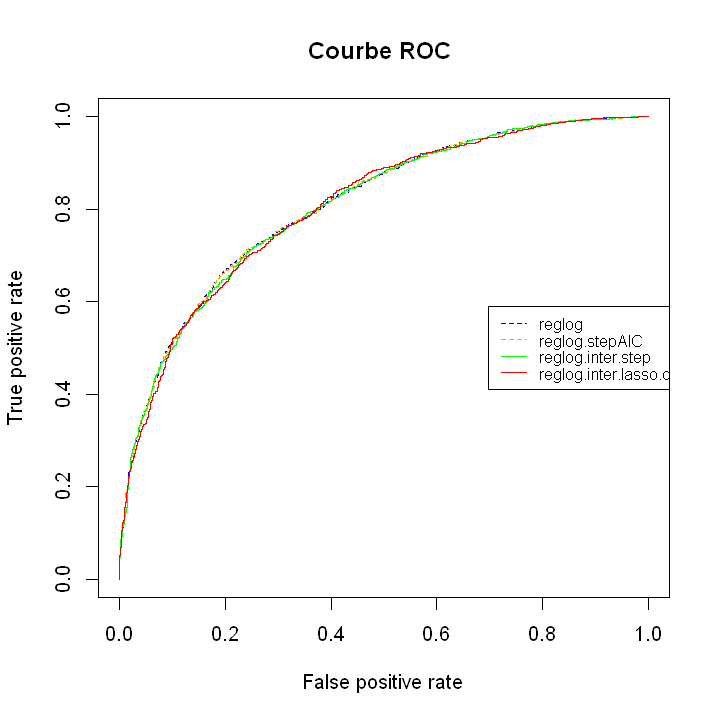

In [46]:
options(repr.plot.width = 6, repr.plot.height = 6)
par(mfrow = c(1, 1))

# modèle sans interaction sans selection de variable
predlogit <- prediction(pred.log, dataTest[, "Heart_Disease_Risk"])
perflogit <- performance(predlogit, "tpr", "fpr")

#Prévision modèle sans interaction avec selection de variable
predlogit.step <- prediction(pred.log.step, dataTest[, "Heart_Disease_Risk"])
perflogit.step <- performance(predlogit.step, "tpr", "fpr")

#Prévision modèle avec interaction par stepAIC
predlogit.interstep <- prediction(pred.log.inter.step, dataTest[, "Heart_Disease_Risk"])
perflogit.inter.step <- performance(predlogit.interstep, "tpr", "fpr")

#Prévision modèle avec interaction par lasso
predlogit.inter.lasso <- prediction(pred.log.inter.lasso, dataTest[, "Heart_Disease_Risk"])
perflogit.inter.lasso <- performance(predlogit.inter.lasso, "tpr", "fpr")

plot(perflogit, col = "blue",lty=2, main = "Courbe ROC ")
plot(perflogit.step,col="orange",lty=2,add=TRUE)
plot(perflogit.inter.step,col="green",lty=1,add=TRUE) 
plot(perflogit.inter.lasso,col="red",lty=1,add=TRUE) 

legend("right", legend=c("reglog", "reglog.stepAIC", "reglog.inter.step","reglog.inter.lasso.cv"),
       col=c("blue","orange","green","red"), lty=c(2,2,1,1), text.font=1,    cex=0.8)


## Modèle SVM

In [9]:
library(e1071)


Attachement du package : 'e1071'


L'objet suivant est masqué depuis 'package:ggplot2':

    element




Justifier le type de noyau utilisé. On part du principe que les données ne sont pas linéairement séparables (très peu probable). Mais on teste tout les noyaux quand même.

**Noyau lineaire**

Par défaut : C-classification car on a une traite une variable qualitative: introduit des slack variables qu'on contrôle avec le paramètre cost.

In [ ]:
svm.tune = tune.svm(Heart_Disease_Risk ~ ., data = dataTrain,kernel="lin", cost = c(0.01, 0.1, 1, 10, 100))
plot(svm.dis.tune)

In [ ]:
#optimisation
svm.tune = tune.svm(Heart_Disease_Risk ~ ., data = dataTrain, 
                    kernel="linear", 
                    cost = c(0.1, 1, 10),
                    tunecontrol = tune.control(sampling = "cross", cross = 5))

In [ ]:
# apprentissage
svm.dis.tune$best.parameters
svm.dis=svm(DepSeuil~.,data=datappq,cost = svm.reg.tune$best.parameters$cost, 
    gamma = svm.reg.tune$best.parameters$gamma)

In [ ]:
#Erreur de classification
pred.svm=predict(svm.dis,newdata=datestq)
table(pred.svmq,datestq[,"DepSeuil"])

**Noyau Radial**

In [12]:
# optimisation
# cost est paramètre qui permet d'ajuster la tolérance aux points mal classées. Plus il est grand, plus il y en a. 
# gamma permet de régler l'influence d'un point. Plus il est élevé, plus l'influence d'un point est courte.
# kernel par défaut (radial)
svm.tune = tune.svm(Heart_Disease_Risk ~ ., data = dataTrain, cost = c(1,1.25,1.5,1.75,2), 
    gamma = seq(0.02, 0.1, by = 0.02))
plot(svm.dis.tune)

ERROR: Error: objet 'dataTrain' introuvable


In [ ]:
# apprentissage
svm.tune$best.parameters
svm.best=svm(Heart_Disease_Risk~.,data=dataTrain,cost = svm.tune$best.parameters$cost, 
    gamma = svm.tune$best.parameters$gamma)

## Arbres binaires

In [11]:
library(rpart) 
library(rpart.plot)
options(repr.plot.width = 15, repr.plot.height = 10)
help(rpart)
help(rpart.control)

Warning message:
"le package 'rpart.plot' a été compilé avec la version R 4.5.3"


rpart {rpart},R Documentation
formula,"a formula, with a response but no interaction terms. If this is a data frame, it is taken as the model frame (see model.frame)."
data,an optional data frame in which to interpret the variables named in the formula.
weights,optional case weights.
subset,optional expression saying that only a subset of the rows of the data should be used in the fit.
na.action,"the default action deletes all observations for which y is missing, but keeps those in which one or more predictors are missing."
method,"one of ""anova"", ""poisson"", ""class"" or ""exp"". If method is missing then the routine tries to make an intelligent guess. If y is a survival object, then method = ""exp"" is assumed, if y has 2 columns then method = ""poisson"" is assumed, if y is a factor then method = ""class"" is assumed, otherwise method = ""anova"" is assumed. It is wisest to specify the method directly, especially as more criteria may added to the function in future. Alternatively, method can be a list of functions named init, split and eval. Examples are given in the file ‘tests/usersplits.R’ in the sources, and in the vignettes ‘User Written Split Functions’."
model,"if logical: keep a copy of the model frame in the result? If the input value for model is a model frame (likely from an earlier call to the rpart function), then this frame is used rather than constructing new data."
x,keep a copy of the x matrix in the result.
y,keep a copy of the dependent variable in the result. If missing and model is supplied this defaults to FALSE.
parms,"optional parameters for the splitting function. Anova splitting has no parameters. Poisson splitting has a single parameter, the coefficient of variation of the prior distribution on the rates. The default value is 1. Exponential splitting has the same parameter as Poisson. For classification splitting, the list can contain any of: the vector of prior probabilities (component prior), the loss matrix (component loss) or the splitting index (component split). The priors must be positive and sum to 1. The loss matrix must have zeros on the diagonal and positive off-diagonal elements. The splitting index can be gini or information. The default priors are proportional to the data counts, the losses default to 1, and the split defaults to gini."


Dans le cas d'une discrimination, le critère par défaut est l'indice de concentration de Gini ; il est possible de préciser un autre critère (split="information") ainsi que des poids sur les observations, une matrice de coûts de mauvais classement ainsi que des probabilités a priori (`?rpart` pour plus de détails).

cp: complexity parameter, any split that does not decrease the overall lack of fit by a factor cp is not attempted. valeur par defaut: 0.01. On va l'estimer par validantion croisée.


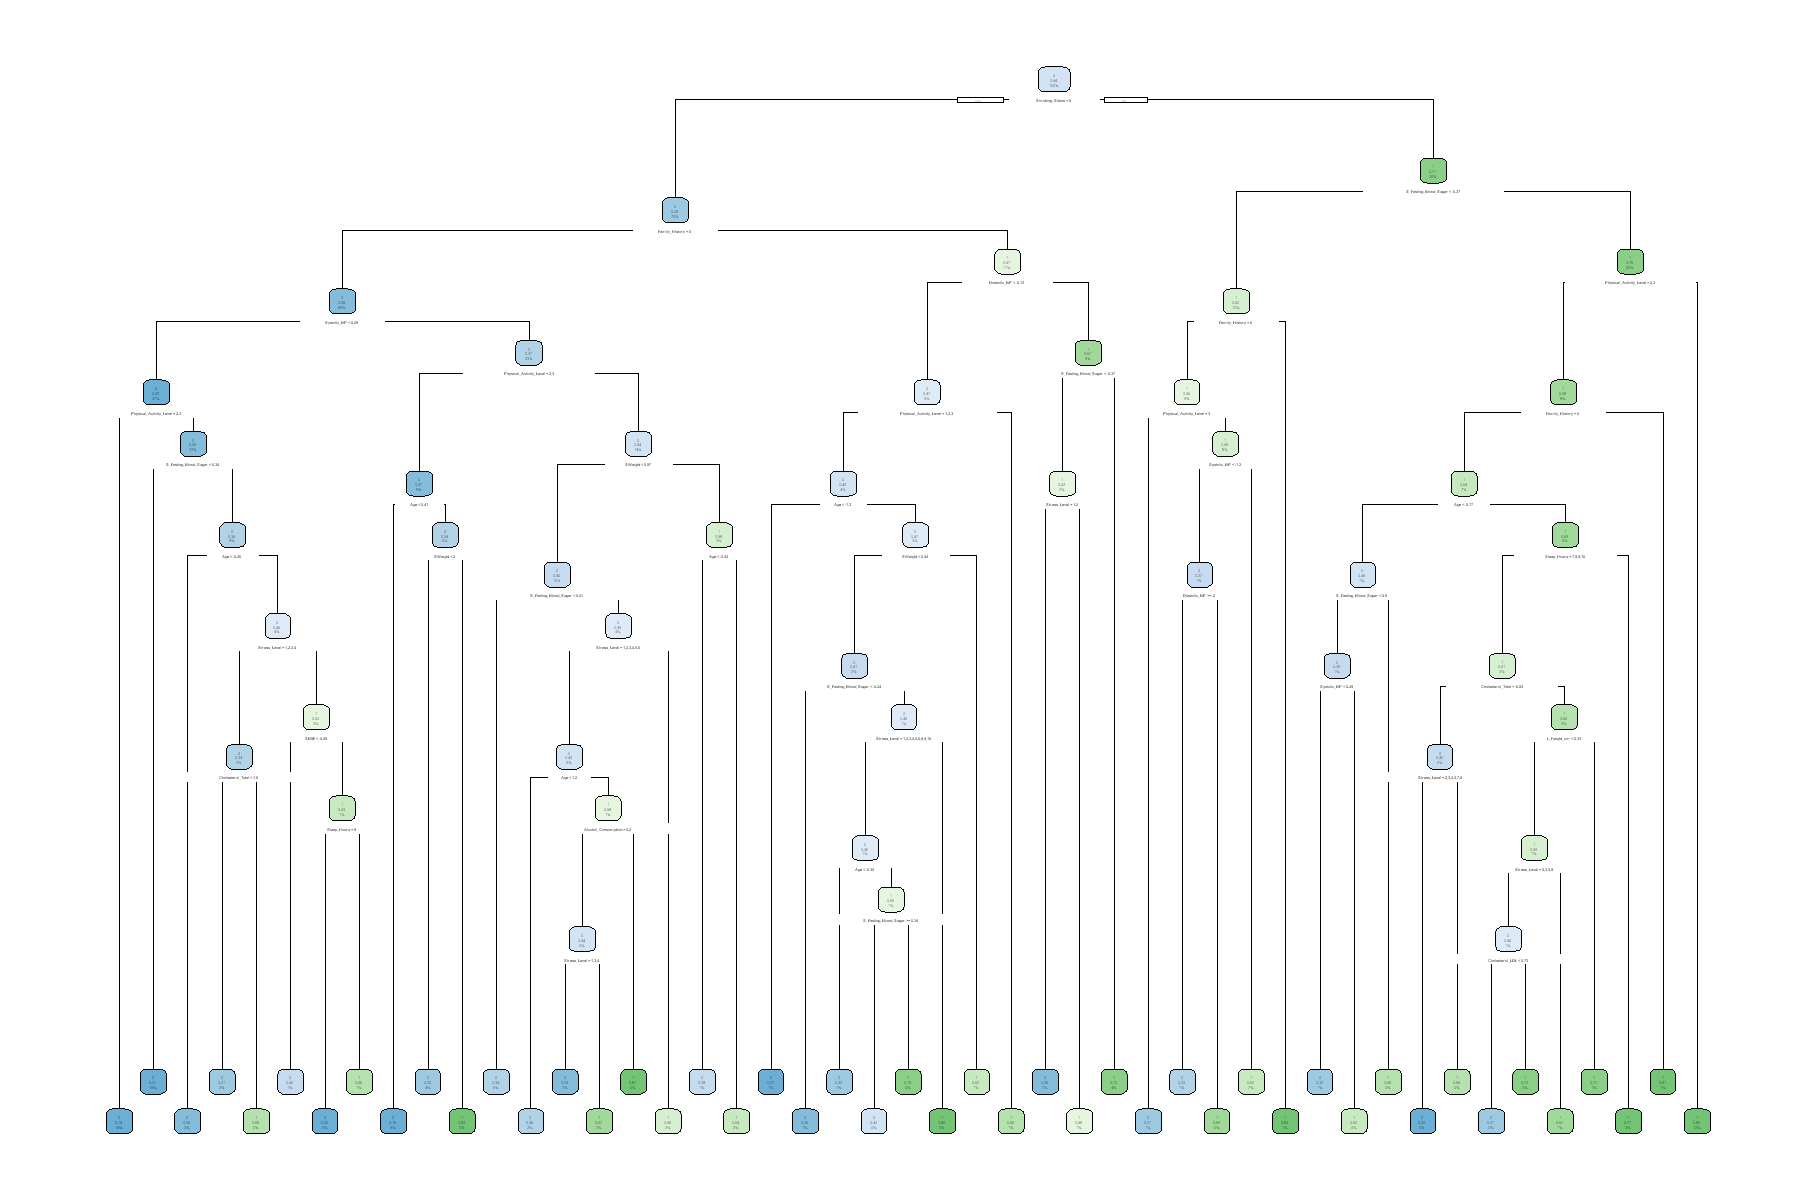

In [12]:
tree=rpart(Heart_Disease_Risk~.,data=dataTrain,parms=list(split="gini"),cp=0.001)
rpart.plot(tree) 
#avec cp=0.001 l'abre est surajusté

In [13]:
#PB ICI 
xmat = xpred.rpart(tree)
head(xmat)
# Comparaison des valeurs prédite et observée
xerr=dataTrain$Heart_Disease_Risk!= (xmat>1.5) 
# Calcul  des estimations des taux d'erreur (taux de mal classées)
CVerr=apply(xerr, 2, sum)/nrow(xerr)
CVerr

,0.641724006,0.101189102,0.016197760,0.005526312,0.003907693,0.003485203,0.003164751,0.002565485,0.002149698,0.001901734,0.001681523,0.001585355,0.001430297,0.001238674,0.001097967,0.001035173,0.001009638
2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
5,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
6,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
8,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


0.641724006 0.101189102 0.016197760 0.005526312 0.003907693 0.003485203 
          1           1           1           1           1           1 
0.003164751 0.002565485 0.002149698 0.001901734 0.001681523 0.001585355 
          1           1           1           1           1           1 
0.001430297 0.001238674 0.001097967 0.001035173 0.001009638 
          1           1           1           1           1

In [14]:
# 1. On transforme le facteur en numérique (1 et 2)
# as.numeric sur un factor donne 1 pour le 1er niveau et 2 pour le 2ème
obs_num <- as.numeric(dataTrain$Heart_Disease_Risk)

# 2. On transforme le test logique en numérique (1 et 2)
# (xmat > 1.5) donne TRUE/FALSE, + 1 donne 1/2
pred_num <- (xmat > 1.5) + 1

# 3. Maintenant la comparaison est possible (Nombre vs Nombre)
xerr = (obs_num != pred_num)

# 4. Calcul des taux d'erreur
CVerr = apply(xerr, 2, sum) / nrow(xerr)
print(CVerr)

0.641724006 0.101189102 0.016197760 0.005526312 0.003907693 0.003485203 
  0.4360000   0.3124167   0.2966667   0.2956667   0.2938333   0.2929167 
0.003164751 0.002565485 0.002149698 0.001901734 0.001681523 0.001585355 
  0.2920000   0.2910000   0.2906667   0.2902500   0.2908333   0.2901667 
0.001430297 0.001238674 0.001097967 0.001035173 0.001009638 
  0.2915000   0.2910833   0.2917500   0.2905833   0.2905833 


[1] "Valeur de cp retenue = 0.001585355"


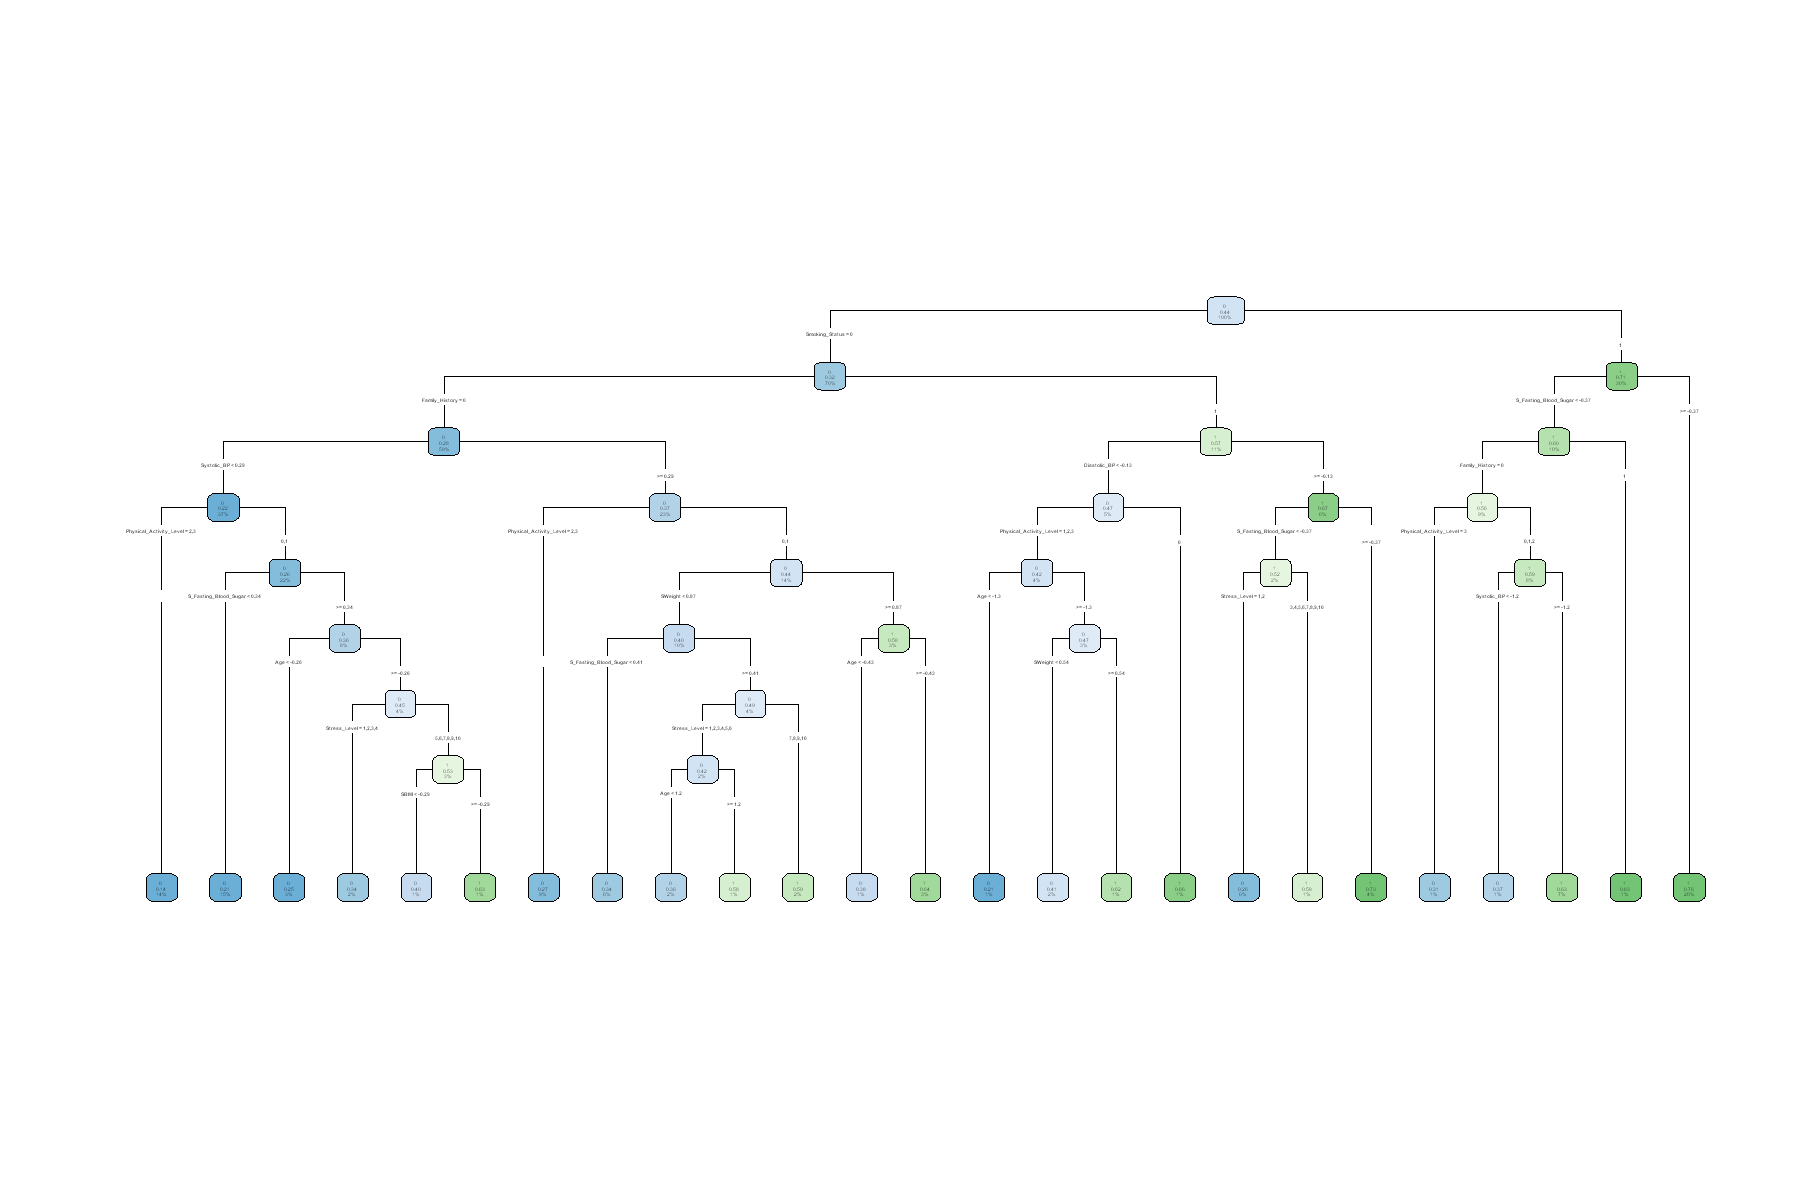

In [15]:
tree=rpart(Heart_Disease_Risk~.,data=dataTrain,parms=list(split="gini"),cp=as.numeric(attributes(which.min(CVerr))$names))
rpart.plot(tree,type=4)
print(paste("Valeur de cp retenue = ",attributes(which.min(CVerr))$names,sep=""))

Avec librairie caret , est ce que c'est different ?

[1] "Valeur de cp retenue = 0.00101936799184506"


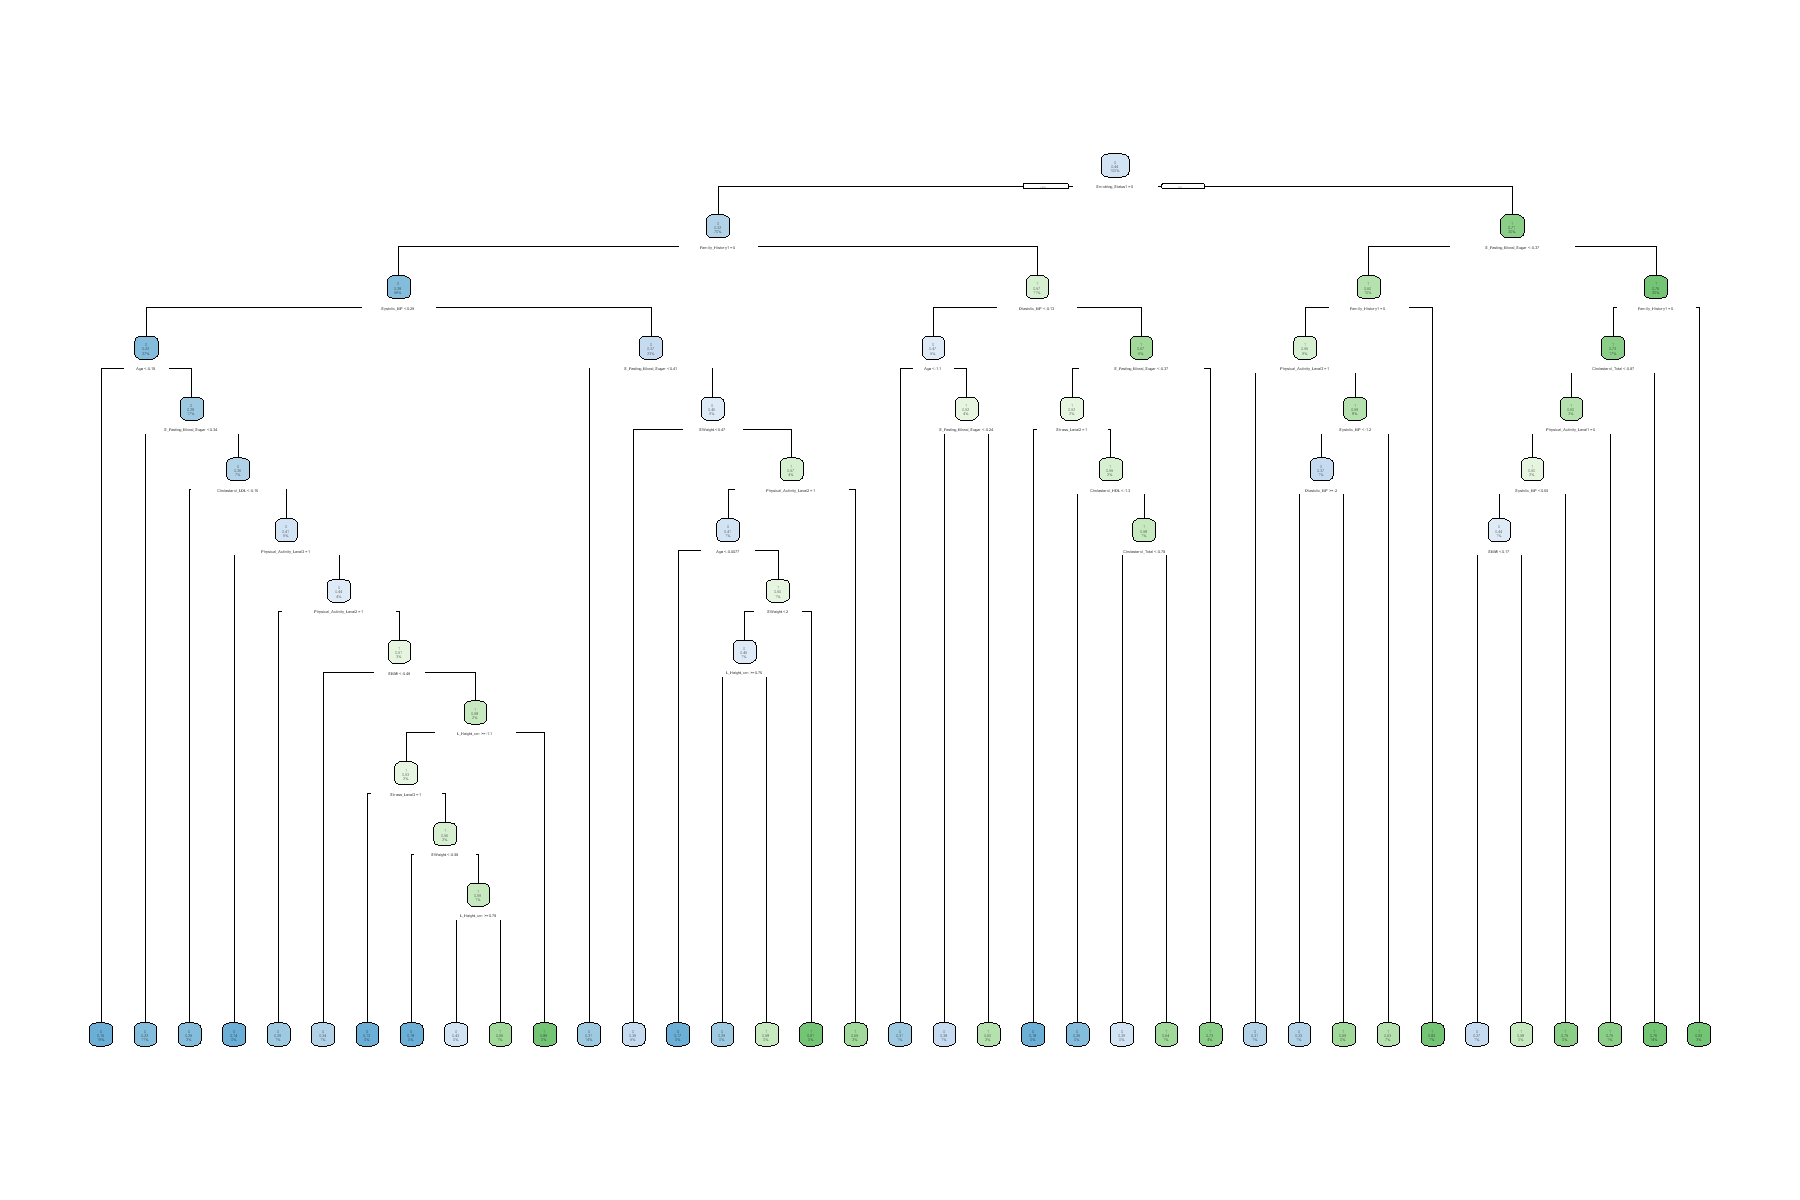

In [16]:
ctrl <- trainControl(method = "cv",number = 10)
treecaret <- train(Heart_Disease_Risk~.,data=dataTrain,method = "rpart",trControl = ctrl,tuneLength =20,metric="Accuracy")
print(paste("Valeur de cp retenue = ",treecaret$bestTune,sep=""))
rpart.plot(treecaret$finalModel)

Erreur de classification echantillon test

In [17]:
pred.tree=predict(tree,newdata=dataTest,type="class")
confusionMatrix(pred.tree,dataTest[,"Heart_Disease_Risk"])$table

          Reference
Prediction    0    1
         0 1311  464
         1  381  844

In [18]:
pred.treecaret = predict(treecaret, newdata = dataTest)
confusionMatrix(pred.treecaret, dataTest$Heart_Disease_Risk)$table

          Reference
Prediction    0    1
         0 1328  508
         1  364  800

In [23]:
nb_feuilles <- sum(tree$frame$var == "<leaf>")
print(paste("Nombre de feuilles de l'abre 1 :", nb_feuilles))
nb_feuilles_caret <- sum(treecaret$finalModel$frame$var == "<leaf>")
print(paste("Nombre de feuilles de l'arbre caret :", nb_feuilles_caret))

[1] "Nombre de feuilles de l'abre 1 : 25"
[1] "Nombre de feuilles de l'arbre caret : 37"


On a tendance a vouloir un arbre le plus simplifié, donc le premier.

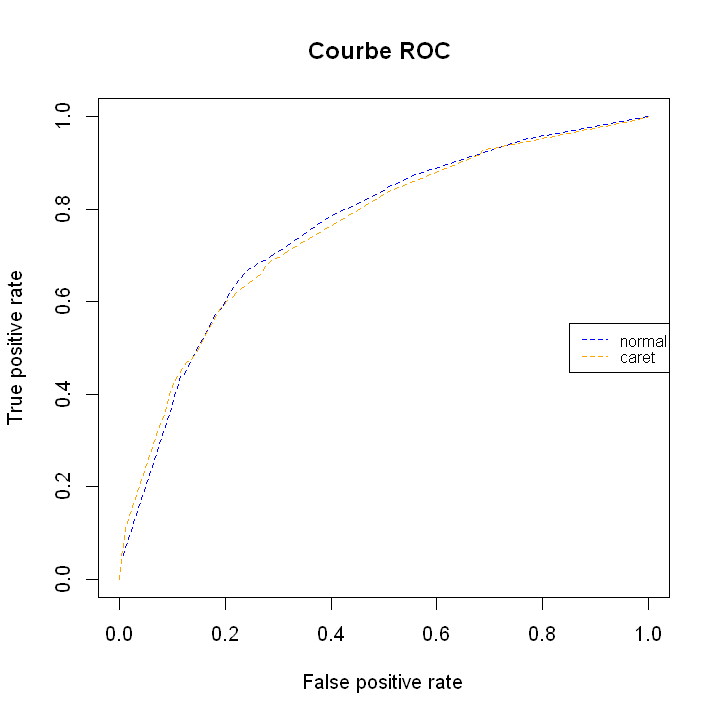

In [22]:
options(repr.plot.width = 6, repr.plot.height = 6)
par(mfrow = c(1, 1))
prob.tree <- predict(tree, newdata = dataTest, type = "prob")[,2] 

# Créer l'objet de prédiction ROCR
pred_rocr_tree <- prediction(prob.tree, dataTest$Heart_Disease_Risk)
perf.tree <- performance(pred_rocr_tree, "tpr", "fpr")

prob.treecaret <- predict(treecaret, newdata = dataTest, type = "prob")[,2]

# Créer l'objet de prédiction ROCR
pred_rocr_caret <- prediction(prob.treecaret, dataTest$Heart_Disease_Risk)
perf.treecaret <- performance(pred_rocr_caret, "tpr", "fpr")


plot(perf.tree, col = "blue",lty=2, main = "Courbe ROC ")
plot(perf.treecaret,col="orange",lty=2,add=TRUE)

legend("right", legend=c("normal", "caret"),
       col=c("blue","orange"), lty=c(2,2,1,1), text.font=1,    cex=0.8)


**changement de critère: information**

In [24]:
tree.info=rpart(Heart_Disease_Risk~.,data=dataTrain,parms=list(split="information"),cp=0.001)
xmat1 = xpred.rpart(tree.info)
# 1. On transforme le facteur en numérique (1 et 2)
# as.numeric sur un factor donne 1 pour le 1er niveau et 2 pour le 2ème
obs_num1 <- as.numeric(dataTrain$Heart_Disease_Risk)

# 2. On transforme le test logique en numérique (1 et 2)
# (xmat > 1.5) donne TRUE/FALSE, + 1 donne 1/2
pred_num1 <- (xmat1 > 1.5) + 1

# 3. Maintenant la comparaison est possible (Nombre vs Nombre)
xerr1 = (obs_num1 != pred_num1)

# 4. Calcul des taux d'erreur
CVerr1 = apply(xerr1, 2, sum) / nrow(xerr1)
tree.info=rpart(Heart_Disease_Risk~.,data=dataTrain,parms=list(split="information"),cp=as.numeric(attributes(which.min(CVerr1))$names))

ctrl <- trainControl(method = "cv",number = 10)
treecaret.info <- train(Heart_Disease_Risk~.,data=dataTrain,method = "rpart",trControl = ctrl,tuneLength =20,metric="Accuracy",parms = list(split = "information"))

Warning message:
"labs do not fit even at cex 0.15, there may be some overplotting"


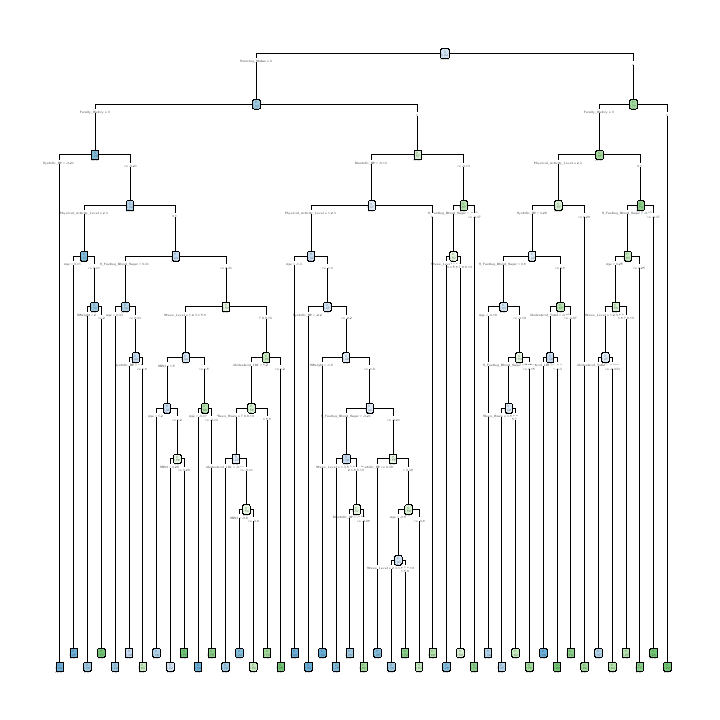

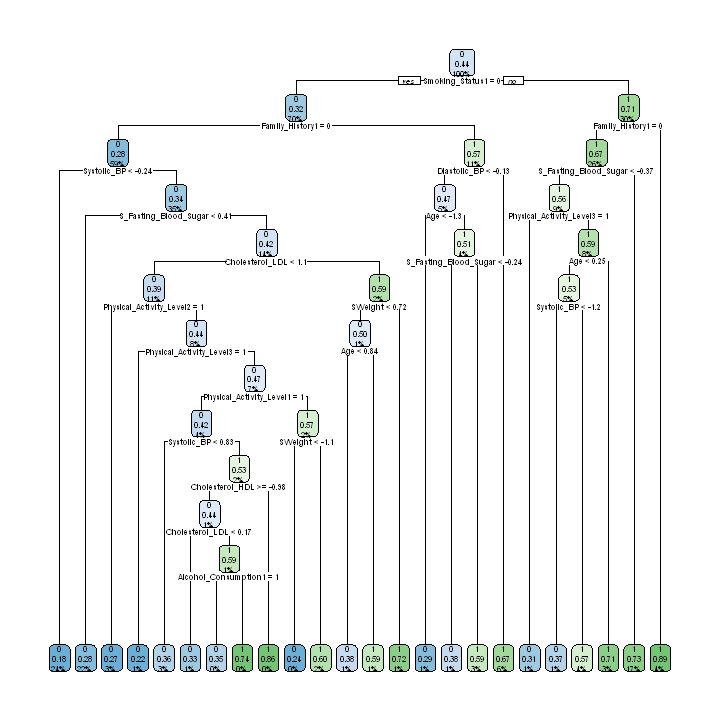

In [25]:
rpart.plot(tree.info,type=4)
rpart.plot(treecaret.info$finalModel)